In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

import joblib

In [3]:
from google.colab import files

uploaded = files.upload()

Saving steel+industry+energy+consumption.zip to steel+industry+energy+consumption.zip


In [7]:
df=pd.read_csv('steel+industry+energy+consumption.zip')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [11]:
df['date'] = pd.to_datetime(
    df['date'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

df['Hour'] = df['date'].dt.hour
df['Day_of_Week'] = df['date'].dt.day_name()
df['Month'] = df['date'].dt.month
df['Weekend'] = df['date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

In [12]:
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] /
    df['Lagging_Current_Power_Factor']
)

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week,Month,Weekend,Power_Factor_Ratio
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,0,1.365934
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,0,1.497679
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,0,1.422880
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,0,1.468644
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,0,1.545117


In [13]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [14]:
target = "Usage_kWh"

X = df.drop(target, axis=1)

y = df[target]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
scaler = StandardScaler()

# Drop the 'date' column from X_train and X_test before scaling
X_train_numeric = X_train.drop('date', axis=1, errors='ignore')
X_test_numeric = X_test.drop('date', axis=1, errors='ignore')

X_train_scaled = scaler.fit_transform(X_train_numeric)

X_test_scaled = scaler.transform(X_test_numeric)

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Impute NaN values in the scaled data before PCA
imputer_pca = SimpleImputer(strategy='mean')
X_train_scaled_imputed = imputer_pca.fit_transform(X_train_scaled)

pca = PCA()

X_train_pca = pca.fit_transform(
    X_train_scaled_imputed
)

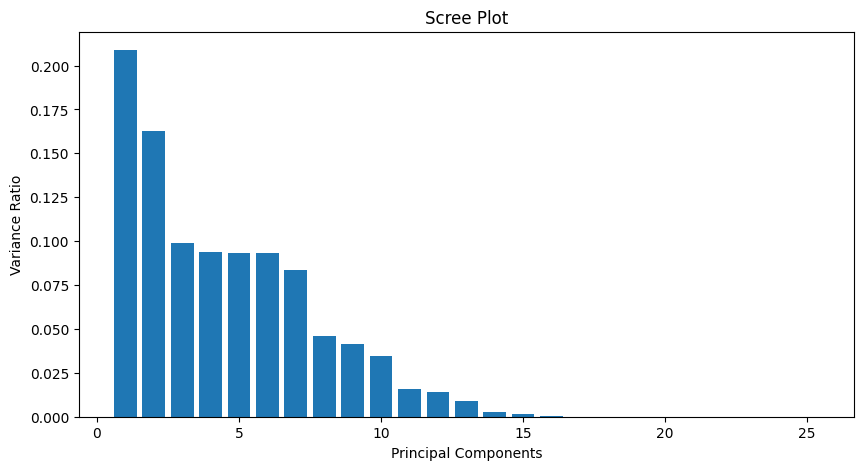

In [26]:
plt.figure(figsize=(10,5))

plt.bar(
    range(1,
    len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.title("Scree Plot")

plt.show()

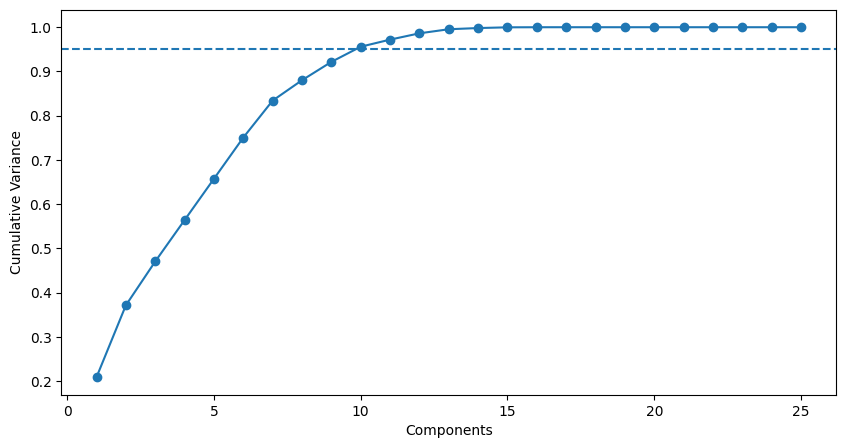

In [27]:
cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")

plt.show()

In [28]:
n_components_95 = np.argmax(
    cum_var >= 0.95
) + 1

print(
    "Components required:",
    n_components_95
)

Components required: 10


In [29]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

pred_original = rf.predict(X_test_scaled)

rmse_original = np.sqrt(
    mean_squared_error(
        y_test,
        pred_original
    )
)

r2_original = r2_score(
    y_test,
    pred_original
)

print("Original RMSE:", rmse_original)
print("Original R2:", r2_original)

Original RMSE: 1.0530597617328372
Original R2: 0.9990244452625733


In [31]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

pca3 = PCA(n_components=3)

# Impute NaN values in X_train_scaled and X_test_scaled before applying PCA
imputer_pca3 = SimpleImputer(strategy='mean')
X_train_scaled_imputed_pca3 = imputer_pca3.fit_transform(X_train_scaled)
X_test_scaled_imputed_pca3 = imputer_pca3.transform(X_test_scaled)

X_train_3 = pca3.fit_transform(
    X_train_scaled_imputed_pca3
)

X_test_3 = pca3.transform(
    X_test_scaled_imputed_pca3
)

rf3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf3.fit(X_train_3, y_train)

pred3 = rf3.predict(X_test_3)

rmse3 = np.sqrt(
    mean_squared_error(
        y_test,
        pred3
    )
)

r23 = r2_score(
    y_test,
    pred3
)

print("PCA 3 RMSE:", rmse3)
print("PCA 3 R2:", r23)

PCA 3 RMSE: 7.254256986731541
PCA 3 R2: 0.9537052781672849


In [33]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

pca95 = PCA(
    n_components=n_components_95
)

# Impute NaN values in X_train_scaled and X_test_scaled before applying PCA
imputer_pca95 = SimpleImputer(strategy='mean')
X_train_scaled_imputed_pca95 = imputer_pca95.fit_transform(X_train_scaled)
X_test_scaled_imputed_pca95 = imputer_pca95.transform(X_test_scaled)

X_train_95 = pca95.fit_transform(
    X_train_scaled_imputed_pca95
)

X_test_95 = pca95.transform(
    X_test_scaled_imputed_pca95
)

rf95 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf95.fit(
    X_train_95,
    y_train
)

pred95 = rf95.predict(
    X_test_95
)

rmse95 = np.sqrt(
    mean_squared_error(
        y_test,
        pred95
    )
)

r295 = r2_score(
    y_test,
    pred95
)

print("PCA95 RMSE:", rmse95)
print("PCA95 R2:", r295)

PCA95 RMSE: 3.3601194987700294
PCA95 R2: 0.9900675805598637


In [34]:
comparison = pd.DataFrame({

    "Model":[
        "Original",
        "PCA 3",
        "PCA 95%"
    ],

    "RMSE":[
        rmse_original,
        rmse3,
        rmse95
    ],

    "R2":[
        r2_original,
        r23,
        r295
    ]
})

comparison

,Model,RMSE,R2
0,Original,1.053060,0.999024
1,PCA 3,7.254257,0.953705
2,PCA 95%,3.360119,0.990068


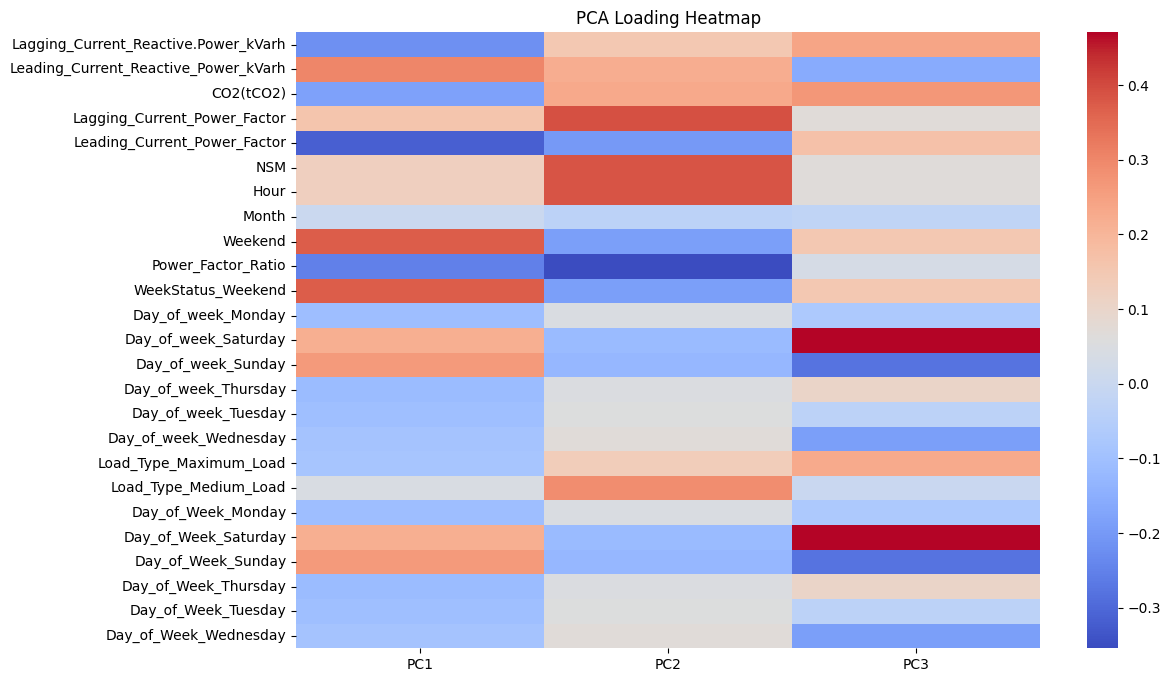

In [36]:
loadings = pd.DataFrame(
    pca3.components_.T,
    columns=["PC1","PC2","PC3"],
    index=X_train_numeric.columns # Corrected index to match the features used for PCA
)

plt.figure(figsize=(12,8))

sns.heatmap(
    loadings,
    cmap="coolwarm"
)

plt.title(
    "PCA Loading Heatmap"
)

plt.show()

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer for handling NaNs within the pipeline

pipeline = Pipeline([
    # Step 1: Impute missing values (if any, as PCA and StandardScaler might encounter them)
    ("imputer", SimpleImputer(strategy='mean')),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_95)),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Drop the 'date' column from X before fitting the pipeline
X_processed = X.drop('date', axis=1, errors='ignore')

pipeline.fit(X_processed, y)

joblib.dump(
    pipeline,
    "model.joblib"
)

print("Saved Successfully")

Saved Successfully
